In [16]:
from torch_snippets import *
from torchvision.datasets import MNIST
from torchvision import transforms
import matplotlib.pyplot as plt
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [2]:
# transformando as imagens
img_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]),
    transforms.Lambda(lambda x: x.to(device))
    ])

In [4]:

# dados de treinno
trn_ds = MNIST('data/', transform=img_transform, train=True, download=True)
# dados de teste
val_ds = MNIST('data/', transform=img_transform, train=False, download=True)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9912422/9912422 [00:56<00:00, 176426.32it/s] 


Extracting data/MNIST/raw/train-images-idx3-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28881/28881 [00:04<00:00, 6633.83it/s]


Extracting data/MNIST/raw/train-labels-idx1-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1648877/1648877 [03:36<00:00, 7602.53it/s]


Extracting data/MNIST/raw/t10k-images-idx3-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4542/4542 [00:00<00:00, 5541.64it/s]

Extracting data/MNIST/raw/t10k-labels-idx1-ubyte.gz to data/MNIST/raw



In [11]:
batch_size = 256
trn_dl = DataLoader(trn_ds, batch_size=batch_size, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

In [12]:
# classe para criar o Autoencoder
class AutoEncoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        self.latend_dim = latent_dim

        # criando as camadas do encoder
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 128), nn.ReLU(True),
            nn.Linear(128, 64), nn.ReLU(True),
            nn.Linear(64, latent_dim)
        )
        # camadas do decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64), nn.ReLU(True),
            nn.Linear(64, 128), nn.ReLU(True),
            nn.Linear(128, 28 * 28), nn.Tanh()
        )

    def forward(self, x):
        x = x.view(len(x), -1)
        x = self.encoder(x)
        x = self.decoder(x)
        x = x.view(len(x), 1, 28, 28)
        return x

In [13]:
# função para treinar o modelo
def train_batch(input, model, criterion, optimizer):
    model.train()
    optimizer.zero_grad()
    output = model(input)
    loss = criterion(output, input)
    loss.backward()
    optimizer.step()
    return loss

# função para validar o modelo
@torch.no_grad()
def validate_batch(input, model, criterion):
    model.eval()
    output = model(input)
    loss = criterion(output, input)
    return loss

EPOCH: 1.000  trn_loss: 0.258  val_loss: 0.195  (7.93s - 31.72s remaining)
EPOCH: 2.000  trn_loss: 0.181  val_loss: 0.168  (14.62s - 21.94s remaining)
EPOCH: 3.000  trn_loss: 0.162  val_loss: 0.157  (21.68s - 14.46s remaining)
EPOCH: 4.000  trn_loss: 0.155  val_loss: 0.152  (28.75s - 7.19s remaining)
EPOCH: 5.000  trn_loss: 0.150  val_loss: 0.147  (36.04s - 0.00s remaining)


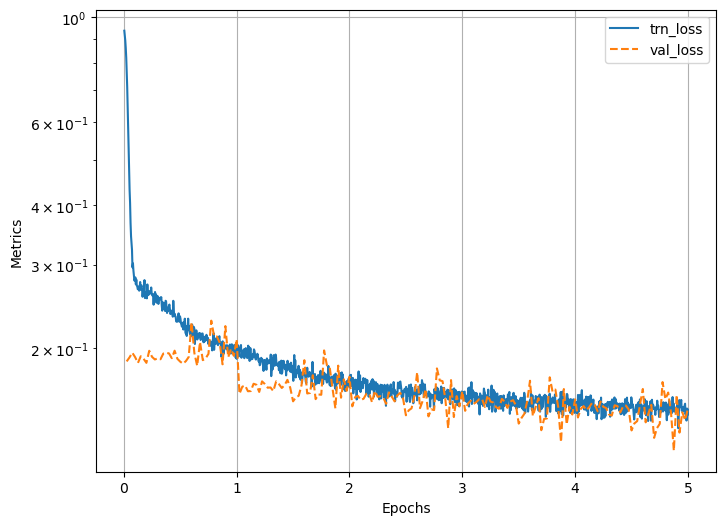

In [14]:
# instanciando modelo
model = AutoEncoder(3).to(device)
# função de calculo de erro
criterion = nn.MSELoss()
# otimizador
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5)

num_epochs = 5
log = Report(num_epochs)

# realizar o treinamento e validação dos dados
for epoch in range(num_epochs):
    N = len(trn_dl)
    for ix, (data, _) in enumerate(trn_dl):
        loss = train_batch(data, model, criterion, optimizer)
        log.record(pos=(epoch + (ix+1)/N), trn_loss=loss, end='\r')

    N = len(val_dl)
    for ix, (data, _) in enumerate(val_dl):
        loss = validate_batch(data, model, criterion)
        log.record(pos=(epoch + (ix+1)/N), val_loss=loss, end='\r')
    
    log.report_avgs(epoch+1)
log.plot(log=True)

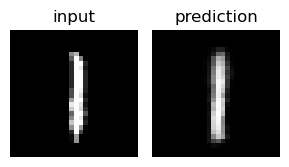

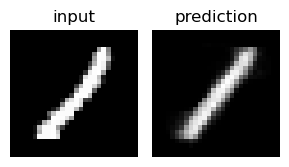

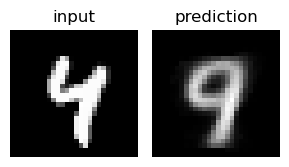

In [17]:
# loop para mostrar as respostas certas e o que foi previsto
for _ in range(3):
    ix = np.random.randint(len(val_ds))
    im, _ = val_ds[ix]
    _im = model(im[None])[0]
    fig, ax = plt.subplots(1, 2, figsize=(3, 3))
    show(im[0], ax=ax[0], title='input')
    show(_im[0], ax=ax[1], title='prediction')
    plt.tight_layout()
    plt.show()

EPOCH: 1.000  trn_loss: 0.235  val_loss: 0.134  (7.48s - 29.92s remaining)
EPOCH: 2.000  trn_loss: 0.113  val_loss: 0.097  (14.41s - 21.61s remaining)
EPOCH: 3.000  trn_loss: 0.090  val_loss: 0.081  (20.82s - 13.88s remaining)
EPOCH: 4.000  trn_loss: 0.079  val_loss: 0.074  (27.45s - 6.86s remaining)
EPOCH: 5.000  trn_loss: 0.073  val_loss: 0.067  (35.16s - 0.00s remaining)


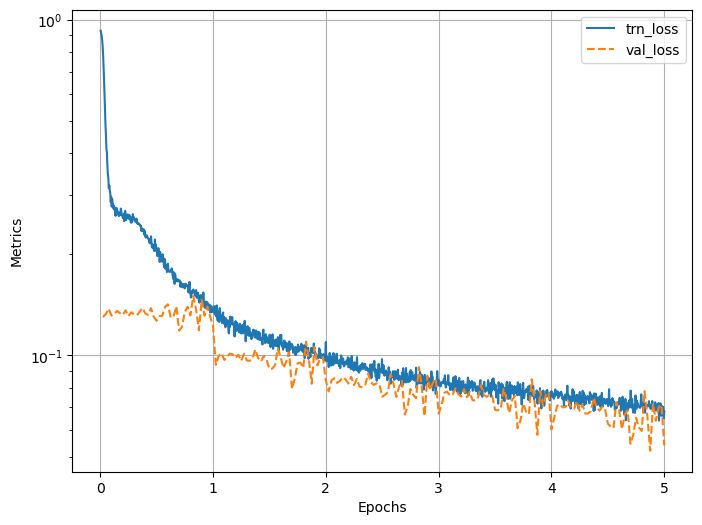

EPOCH: 1.000  trn_loss: 0.270  val_loss: 0.213  (8.69s - 34.77s remaining)
EPOCH: 2.000  trn_loss: 0.196  val_loss: 0.186  (15.46s - 23.19s remaining)
EPOCH: 3.000  trn_loss: 0.181  val_loss: 0.177  (23.67s - 15.78s remaining)
EPOCH: 4.000  trn_loss: 0.174  val_loss: 0.172  (30.30s - 7.58s remaining)
EPOCH: 5.000  trn_loss: 0.171  val_loss: 0.169  (36.30s - 0.00s remaining)


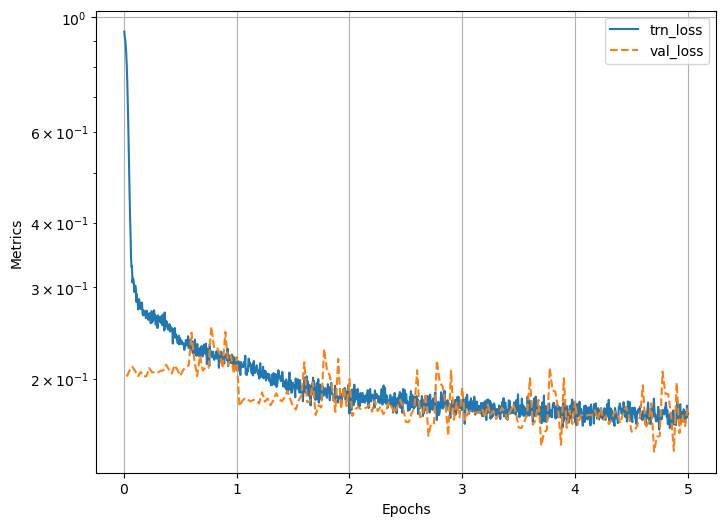

EPOCH: 1.000  trn_loss: 0.261  val_loss: 0.199  (5.57s - 22.29s remaining)
EPOCH: 2.000  trn_loss: 0.183  val_loss: 0.170  (12.22s - 18.33s remaining)
EPOCH: 3.000  trn_loss: 0.162  val_loss: 0.158  (17.72s - 11.81s remaining)
EPOCH: 4.000  trn_loss: 0.154  val_loss: 0.152  (23.50s - 5.87s remaining)
EPOCH: 5.000  trn_loss: 0.150  val_loss: 0.148  (29.39s - 0.00s remaining)


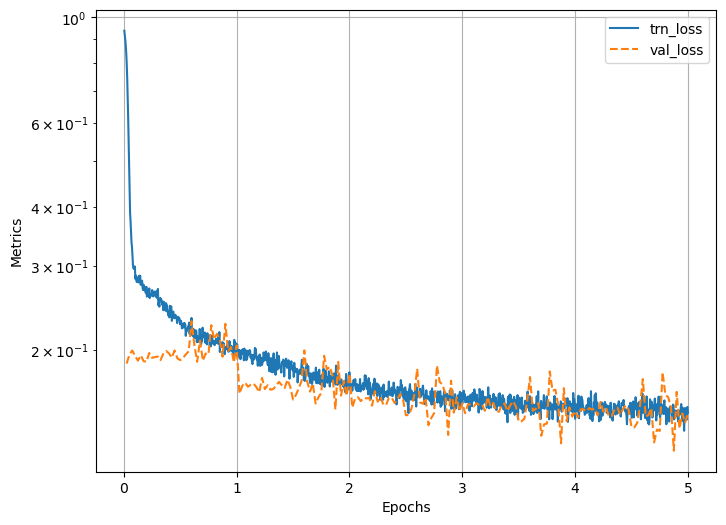

EPOCH: 1.000  trn_loss: 0.244  val_loss: 0.162  (5.43s - 21.71s remaining)
EPOCH: 2.000  trn_loss: 0.147  val_loss: 0.137  (10.83s - 16.24s remaining)
EPOCH: 3.000  trn_loss: 0.131  val_loss: 0.127  (16.43s - 10.95s remaining)
EPOCH: 4.000  trn_loss: 0.124  val_loss: 0.122  (22.18s - 5.55s remaining)
EPOCH: 5.000  trn_loss: 0.120  val_loss: 0.119  (27.93s - 0.00s remaining)


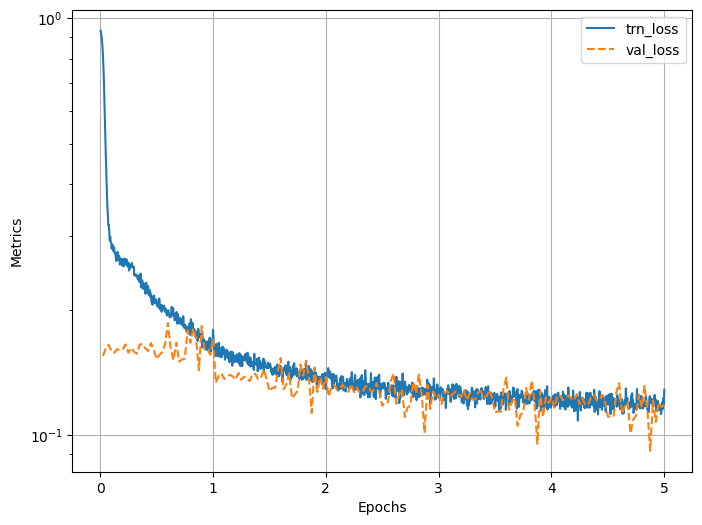

EPOCH: 1.000  trn_loss: 0.243  val_loss: 0.154  (5.56s - 22.25s remaining)
EPOCH: 2.000  trn_loss: 0.132  val_loss: 0.117  (11.11s - 16.66s remaining)
EPOCH: 3.000  trn_loss: 0.110  val_loss: 0.103  (16.64s - 11.09s remaining)
EPOCH: 4.000  trn_loss: 0.101  val_loss: 0.096  (22.46s - 5.61s remaining)
EPOCH: 5.000  trn_loss: 0.096  val_loss: 0.092  (28.38s - 0.00s remaining)


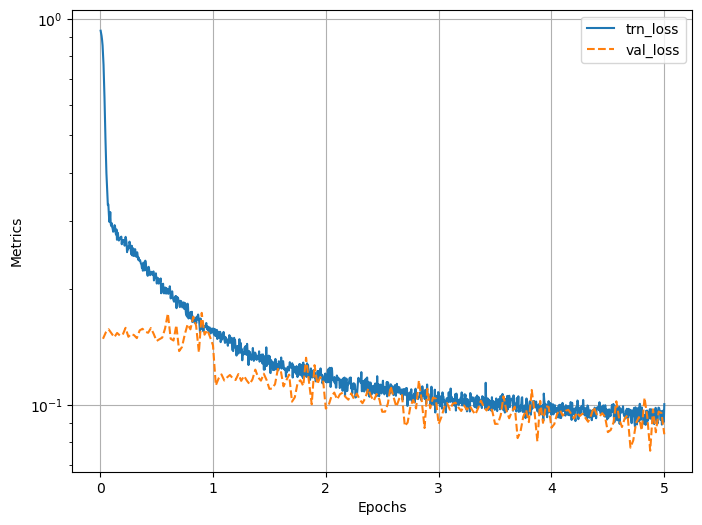

In [18]:
# função para treinar o auto encoder
def train_aec(latent_dim):

    # instanciando novamente as informações
    model = AutoEncoder(latent_dim).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-5)

    num_epochs = 5
    log = Report(num_epochs)

    # rodando as épocas
    for epoch in range(num_epochs):
        N = len(trn_dl)
        for ix, (data, _) in enumerate(trn_dl):
            loss = train_batch(data, model, criterion, optimizer)
            log.record(pos=(epoch + (ix+1)/N), trn_loss=loss, end='\r')

        N = len(val_dl)
        for ix, (data, _) in enumerate(val_dl):
            loss = validate_batch(data, model, criterion)
            log.record(pos=(epoch + (ix+1)/N), val_loss=loss, end='\r')
        
        log.report_avgs(epoch+1)
    log.plot(log=True)
    return model

aecs = [train_aec(dim) for dim in [50, 2, 3, 5, 10]]

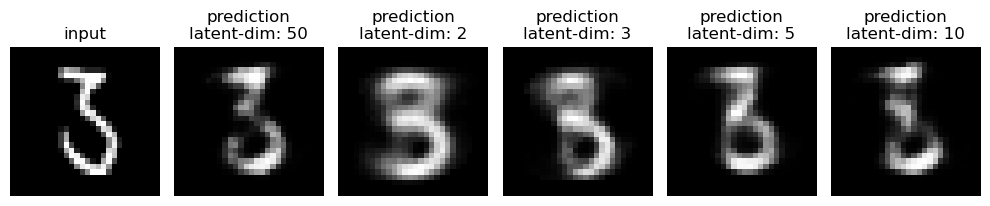

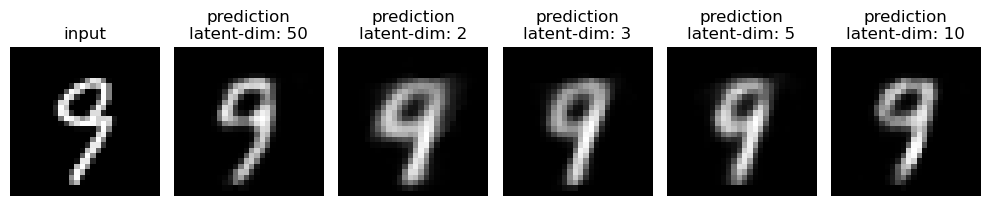

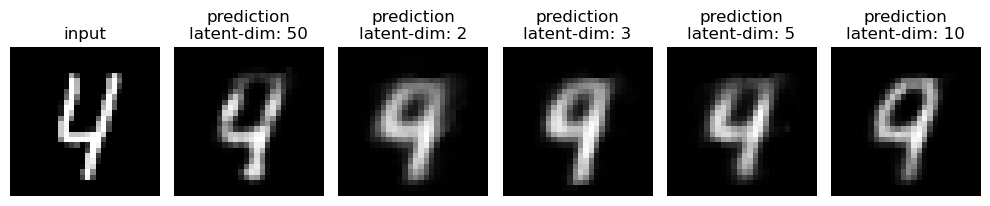

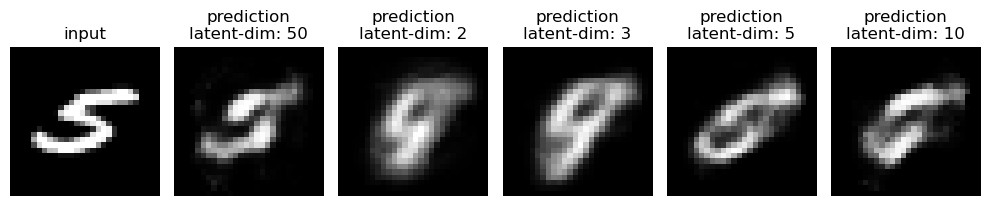

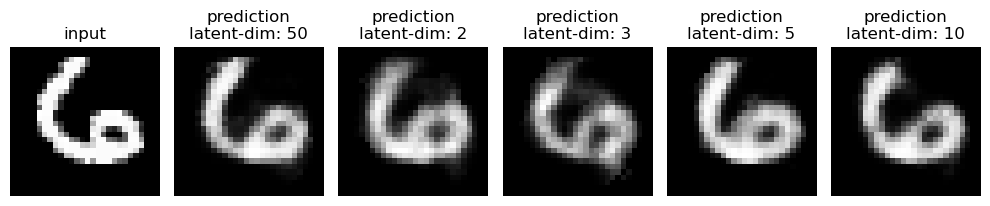

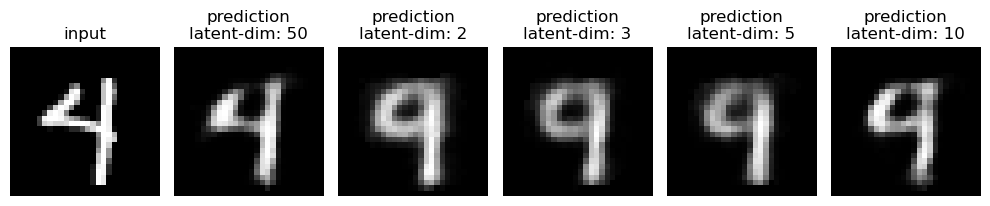

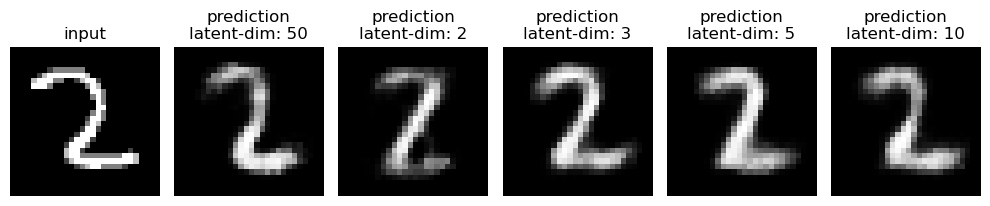

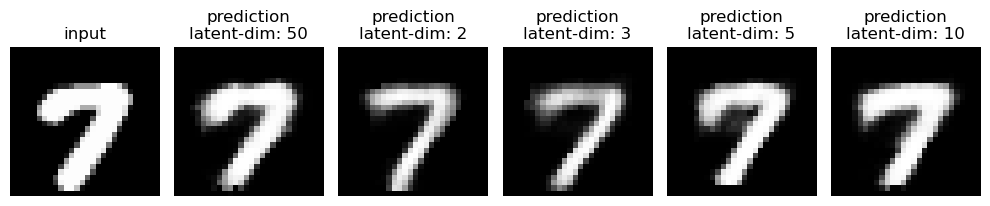

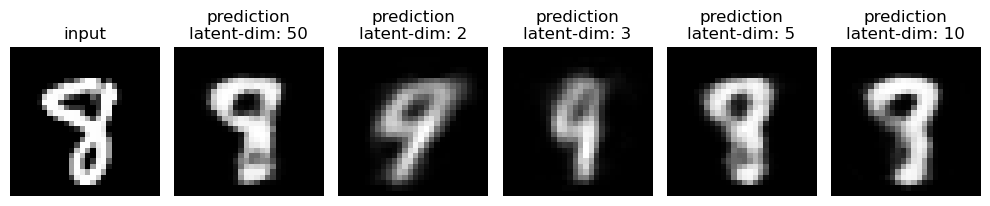

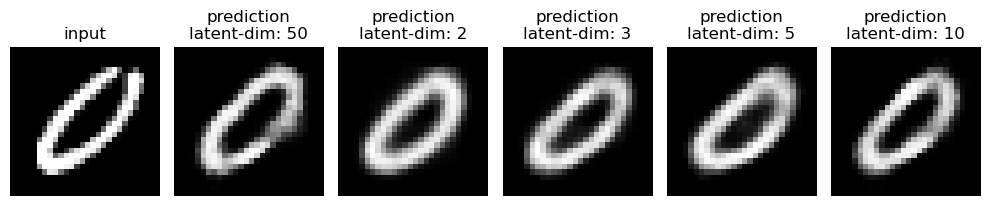

In [19]:
# mesmo loop para mostrar as imagens das respostas e previsões
for _ in range(10):
    ix = np.random.randint(len(val_ds))
    im, _ = val_ds[ix]
    fig, ax = plt.subplots(1, len(aecs)+1, figsize=(10, 4))
    ax = iter(ax.flat)
    show(im[0], ax=next(ax), title='input')
    for model in aecs:
        _im = model(im[None])[0]
        show(_im[0], ax=next(ax), title=f'prediction\nlatent-dim: {model.latend_dim}')
    plt.tight_layout()
    plt.show()